<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/disability/word_cloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install matplotlib wordcloud pandas nltk

### Load Data and Preprocess Comments

First, we'll load the `youtube_comments.csv` file into a pandas DataFrame. Then, we'll extract the 'comment' column and preprocess the text by removing punctuation, converting to lowercase, and removing common English stop words. This prepares the text for generating a meaningful word cloud.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import nltk

# Download NLTK data (only needs to be run once)
# try:
#     nltk.data.find('corpora/stopwords')
# except LookupError:
#     nltk.download('stopwords')
# try:
#     nltk.data.find('tokenizers/punkt')
# except LookupError:
#     nltk.download('punkt')
# # Explicitly download 'punkt_tab' as indicated by the error message
# try:
#     nltk.data.find('tokenizers/punkt_tab')
# except LookupError:
#     nltk.download('punkt_tab')

# Load the dataset
df = pd.read_csv('combined_data.csv')

# Combine 'title' and 'content' columns into a single string for each row
df['combined_text'] = df['title'].fillna('') + ' ' + df['content'].fillna('')

# Combine all combined_text into a single string
all_comments = ' '.join(df['combined_text'].astype(str).tolist())

# Text preprocessing
def preprocess_text(text):
    # Remove non-alphabetic characters and convert to lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    # Tokenize words
    words = word_tokenize(text)
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    stop_words.add("even")
    stop_words.add("one")
    stop_words.add("still")
    words = [word for word in words if word not in stop_words and len(word) > 2] # Remove short words
    return ' '.join(words)

processed_comments = preprocess_text(all_comments)

print(f"Original comments length: {len(all_comments)}")
print(f"Processed comments length: {len(processed_comments)}")

Original comments length: 33456335
Processed comments length: 21417145


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6370 entries, 0 to 6369
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          6370 non-null   object
 1   content        6186 non-null   object
 2   created        6370 non-null   object
 3   combined_text  6370 non-null   object
dtypes: object(4)
memory usage: 199.2+ KB


In [28]:
import re
eng = re.compile("[^a-zA-Z]")

#전처리 이모티콘, 특수문자 등 제거, 소문자 치환
#통상적으로 숫자도 지운다
df['combined_text'] = df['combined_text'].apply(lambda x: x.lower())
# Remove URLs
df['combined_text'] = df['combined_text'].apply(lambda x: re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', x))
df['combined_text'] = df['combined_text'].apply(lambda x: re.sub(eng, " ",x))
df['combined_text'] = df['combined_text'].apply(lambda x: x.strip())
df

,title,content,created,combined_text
0,Transferring wheelchair tickets of M52 in Seat...,https://preview.redd.it/r22k6adtnf2h1.png?widt...,2026-05-21 15:27:59,transferring wheelchair tickets of m in seat...
1,SNF/LTC nurses not giving PRN morphine,I’m a newer nurse with a little over a year of...,2026-05-21 13:21:55,snf ltc nurses not giving prn morphine i m a n...
2,first power chair!,right here is a refurbished pride go chair fro...,2026-05-21 12:41:53,first power chair right here is a refurbished...
3,A Tale of State-Sanctioned Torture (On the Sub...,"Hello, comrades! I’m an old member here who ha...",2026-05-21 12:03:30,a tale of state sanctioned torture on the sub...
4,Moving to San Leandro this year! So excited!,"I am proud to announce that I, a 33 year old s...",2026-05-21 07:01:00,moving to san leandro this year so excited i...
...,...,...,...,...
6365,AIO to my wife lying about Snapchat messages,Throwaway for privacy and I don’t post ever so...,2026-01-28 00:51:44,aio to my wife lying about snapchat messages t...
6366,The Gravity of the Situation 16: An Out of Cru...,\n\nMuch thanks to [u/KyleKKent](https://www....,2026-01-25 04:08:53,the gravity of the situation an out of cru...
6367,Is this a good price?,Hi! So recently I took my car in to check for ...,2026-01-25 04:08:12,is this a good price hi so recently i took m...
6368,Wheelchair/Walker local repair,Just wanted to put the word out that we have a...,2026-01-25 04:02:38,wheelchair walker local repair just wanted to ...


In [29]:
#성의 없는 30단어 미만 리뷰 제거

df['length'] = df['combined_text'].apply(lambda x: len(x))
df = df.loc[df['length']>=30]
df.reset_index(drop = True)
del df['length']
df

,title,content,created,combined_text
0,Transferring wheelchair tickets of M52 in Seat...,https://preview.redd.it/r22k6adtnf2h1.png?widt...,2026-05-21 15:27:59,transferring wheelchair tickets of m in seat...
1,SNF/LTC nurses not giving PRN morphine,I’m a newer nurse with a little over a year of...,2026-05-21 13:21:55,snf ltc nurses not giving prn morphine i m a n...
2,first power chair!,right here is a refurbished pride go chair fro...,2026-05-21 12:41:53,first power chair right here is a refurbished...
3,A Tale of State-Sanctioned Torture (On the Sub...,"Hello, comrades! I’m an old member here who ha...",2026-05-21 12:03:30,a tale of state sanctioned torture on the sub...
4,Moving to San Leandro this year! So excited!,"I am proud to announce that I, a 33 year old s...",2026-05-21 07:01:00,moving to san leandro this year so excited i...
...,...,...,...,...
6365,AIO to my wife lying about Snapchat messages,Throwaway for privacy and I don’t post ever so...,2026-01-28 00:51:44,aio to my wife lying about snapchat messages t...
6366,The Gravity of the Situation 16: An Out of Cru...,\n\nMuch thanks to [u/KyleKKent](https://www....,2026-01-25 04:08:53,the gravity of the situation an out of cru...
6367,Is this a good price?,Hi! So recently I took my car in to check for ...,2026-01-25 04:08:12,is this a good price hi so recently i took m...
6368,Wheelchair/Walker local repair,Just wanted to put the word out that we have a...,2026-01-25 04:02:38,wheelchair walker local repair just wanted to ...


In [30]:
#TOKENIZING

df['token'] = df['combined_text'].apply(lambda x : word_tokenize(x))
df

/tmp/ipykernel_2930/1578167665.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['token'] = df['combined_text'].apply(lambda x : word_tokenize(x))


,title,content,created,combined_text,token
0,Transferring wheelchair tickets of M52 in Seat...,https://preview.redd.it/r22k6adtnf2h1.png?widt...,2026-05-21 15:27:59,transferring wheelchair tickets of m in seat...,"[transferring, wheelchair, tickets, of, m, in,..."
1,SNF/LTC nurses not giving PRN morphine,I’m a newer nurse with a little over a year of...,2026-05-21 13:21:55,snf ltc nurses not giving prn morphine i m a n...,"[snf, ltc, nurses, not, giving, prn, morphine,..."
2,first power chair!,right here is a refurbished pride go chair fro...,2026-05-21 12:41:53,first power chair right here is a refurbished...,"[first, power, chair, right, here, is, a, refu..."
3,A Tale of State-Sanctioned Torture (On the Sub...,"Hello, comrades! I’m an old member here who ha...",2026-05-21 12:03:30,a tale of state sanctioned torture on the sub...,"[a, tale, of, state, sanctioned, torture, on, ..."
4,Moving to San Leandro this year! So excited!,"I am proud to announce that I, a 33 year old s...",2026-05-21 07:01:00,moving to san leandro this year so excited i...,"[moving, to, san, leandro, this, year, so, exc..."
...,...,...,...,...,...
6365,AIO to my wife lying about Snapchat messages,Throwaway for privacy and I don’t post ever so...,2026-01-28 00:51:44,aio to my wife lying about snapchat messages t...,"[aio, to, my, wife, lying, about, snapchat, me..."
6366,The Gravity of the Situation 16: An Out of Cru...,\n\nMuch thanks to [u/KyleKKent](https://www....,2026-01-25 04:08:53,the gravity of the situation an out of cru...,"[the, gravity, of, the, situation, an, out, of..."
6367,Is this a good price?,Hi! So recently I took my car in to check for ...,2026-01-25 04:08:12,is this a good price hi so recently i took m...,"[is, this, a, good, price, hi, so, recently, i..."
6368,Wheelchair/Walker local repair,Just wanted to put the word out that we have a...,2026-01-25 04:02:38,wheelchair walker local repair just wanted to ...,"[wheelchair, walker, local, repair, just, want..."


In [31]:
token = []
for i in df['token']:
    tok = []
    for w in i:
        if w in stop_words:
            pass
        else:
            tok.append(w)
    token.append(tok)
df['token'] = token
df

/tmp/ipykernel_2930/467019179.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['token'] = token


,title,content,created,combined_text,token
0,Transferring wheelchair tickets of M52 in Seat...,https://preview.redd.it/r22k6adtnf2h1.png?widt...,2026-05-21 15:27:59,transferring wheelchair tickets of m in seat...,"[transferring, wheelchair, tickets, seattle, f..."
1,SNF/LTC nurses not giving PRN morphine,I’m a newer nurse with a little over a year of...,2026-05-21 13:21:55,snf ltc nurses not giving prn morphine i m a n...,"[snf, ltc, nurses, giving, prn, morphine, newe..."
2,first power chair!,right here is a refurbished pride go chair fro...,2026-05-21 12:41:53,first power chair right here is a refurbished...,"[first, power, chair, right, refurbished, prid..."
3,A Tale of State-Sanctioned Torture (On the Sub...,"Hello, comrades! I’m an old member here who ha...",2026-05-21 12:03:30,a tale of state sanctioned torture on the sub...,"[tale, state, sanctioned, torture, subject, fr..."
4,Moving to San Leandro this year! So excited!,"I am proud to announce that I, a 33 year old s...",2026-05-21 07:01:00,moving to san leandro this year so excited i...,"[moving, san, leandro, year, excited, proud, a..."
...,...,...,...,...,...
6365,AIO to my wife lying about Snapchat messages,Throwaway for privacy and I don’t post ever so...,2026-01-28 00:51:44,aio to my wife lying about snapchat messages t...,"[aio, wife, lying, snapchat, messages, throwaw..."
6366,The Gravity of the Situation 16: An Out of Cru...,\n\nMuch thanks to [u/KyleKKent](https://www....,2026-01-25 04:08:53,the gravity of the situation an out of cru...,"[gravity, situation, cruel, space, side, story..."
6367,Is this a good price?,Hi! So recently I took my car in to check for ...,2026-01-25 04:08:12,is this a good price hi so recently i took m...,"[good, price, hi, recently, took, car, check, ..."
6368,Wheelchair/Walker local repair,Just wanted to put the word out that we have a...,2026-01-25 04:02:38,wheelchair walker local repair just wanted to ...,"[wheelchair, walker, local, repair, wanted, pu..."


In [32]:
#어근 추출
#목적에 따라서 적절한 방법 선택 필요
from nltk.stem import WordNetLemmatizer, PorterStemmer
nltk.download('wordnet')
lemmatizer =WordNetLemmatizer()
stemmer = PorterStemmer()
print([lemmatizer.lemmatize(word) for word in df['token'][0]]) #품사 유지
print(" ")
print([stemmer.stem(word) for word in df['token'][0]]) #어근, 어원

#춤을 추다
# lemmatize => 춤, 추다
# stem => 추

['transferring', 'wheelchair', 'ticket', 'seattle', 'face', 'value', 'hey', 'made', 'stupid', 'mistake', 'purchasing', 'ticket', 'got', 'wheelchair', 'ticket', 'go', 'accessibility', 'permit', 'none', 'family', 'friend', 'asking', 'original', 'price', 'ticket', 'also', 'seattle', 'want', 'face', 'face', 'need', 'pay', 'transfer', 'ticket', 'account']
 
['transfer', 'wheelchair', 'ticket', 'seattl', 'face', 'valu', 'hey', 'made', 'stupid', 'mistak', 'purchas', 'ticket', 'got', 'wheelchair', 'ticket', 'go', 'access', 'permit', 'none', 'famili', 'friend', 'ask', 'origin', 'price', 'ticket', 'also', 'seattl', 'want', 'face', 'face', 'need', 'pay', 'transfer', 'ticket', 'account']


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [33]:
df['token'] = df['token'].apply(lambda x: [stemmer.stem(word) for word in x])
df

/tmp/ipykernel_2930/1031796120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['token'] = df['token'].apply(lambda x: [stemmer.stem(word) for word in x])


,title,content,created,combined_text,token
0,Transferring wheelchair tickets of M52 in Seat...,https://preview.redd.it/r22k6adtnf2h1.png?widt...,2026-05-21 15:27:59,transferring wheelchair tickets of m in seat...,"[transfer, wheelchair, ticket, seattl, face, v..."
1,SNF/LTC nurses not giving PRN morphine,I’m a newer nurse with a little over a year of...,2026-05-21 13:21:55,snf ltc nurses not giving prn morphine i m a n...,"[snf, ltc, nurs, give, prn, morphin, newer, nu..."
2,first power chair!,right here is a refurbished pride go chair fro...,2026-05-21 12:41:53,first power chair right here is a refurbished...,"[first, power, chair, right, refurbish, pride,..."
3,A Tale of State-Sanctioned Torture (On the Sub...,"Hello, comrades! I’m an old member here who ha...",2026-05-21 12:03:30,a tale of state sanctioned torture on the sub...,"[tale, state, sanction, tortur, subject, freed..."
4,Moving to San Leandro this year! So excited!,"I am proud to announce that I, a 33 year old s...",2026-05-21 07:01:00,moving to san leandro this year so excited i...,"[move, san, leandro, year, excit, proud, annou..."
...,...,...,...,...,...
6365,AIO to my wife lying about Snapchat messages,Throwaway for privacy and I don’t post ever so...,2026-01-28 00:51:44,aio to my wife lying about snapchat messages t...,"[aio, wife, lie, snapchat, messag, throwaway, ..."
6366,The Gravity of the Situation 16: An Out of Cru...,\n\nMuch thanks to [u/KyleKKent](https://www....,2026-01-25 04:08:53,the gravity of the situation an out of cru...,"[graviti, situat, cruel, space, side, stori, m..."
6367,Is this a good price?,Hi! So recently I took my car in to check for ...,2026-01-25 04:08:12,is this a good price hi so recently i took m...,"[good, price, hi, recent, took, car, check, pr..."
6368,Wheelchair/Walker local repair,Just wanted to put the word out that we have a...,2026-01-25 04:02:38,wheelchair walker local repair just wanted to ...,"[wheelchair, walker, local, repair, want, put,..."


### Generate and Display Word Cloud

Now, we'll use the preprocessed text to generate a word cloud. The word cloud visually represents the frequency of words, with larger words indicating higher frequency.

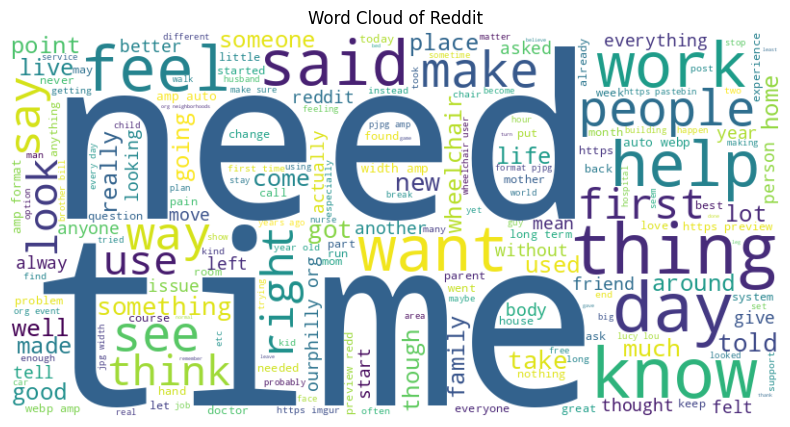

In [34]:

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(processed_comments)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Reddit')
plt.show()

In [35]:
from google.colab import drive
drive.mount('/content/drive')

# 코랩 konlpy 실행
!curl -s https://raw.githubusercontent.com/teddylee777/machine-learning/master/99-Misc/01-Colab/mecab-colab.sh | bash

# Mecab 설치 후 Google Drive에 복사
!cp -r /usr/local/lib/mecab /content/drive/MyDrive/mecab
!cp -r /usr/local/etc/mecabrc /content/drive/MyDrive/mecab

!pip install kiwipiepy
import pandas as pd
from kiwipiepy import Kiwi
from kiwipiepy.utils import Stopwords
from konlpy.tag import Okt
from tqdm import tqdm

Mounted at /content/drive
--2026-05-22 07:24:36--  https://www.dropbox.com/s/9xls0tgtf3edgns/mecab-0.996-ko-0.9.2.tar.gz?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.83.18, 2620:100:6023:18::a27d:4312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.83.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/g8l6dlu5a3ebovcdymluq/mecab-0.996-ko-0.9.2.tar.gz?rlkey=xlooryouhr1l2ufqbt93ohfvy&dl=1 [following]
--2026-05-22 07:24:37--  https://www.dropbox.com/scl/fi/g8l6dlu5a3ebovcdymluq/mecab-0.996-ko-0.9.2.tar.gz?rlkey=xlooryouhr1l2ufqbt93ohfvy&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://ucf493c5c484011c525971b94581.dl.dropboxusercontent.com/cd/0/inline/DA7lRXPVI7GeY2OG49KPWdTb9cyvGtm_AJ0PDAEQ7QI2nPqKmqkj85-y2cgXbw_t2fdayVMeb5KNVMwfAQGHCkGHRUI0I_nbqnvZzdpvNj7QXMtpCowPEnHDrckiLl6QXEhE4CxVzyEeh7RwDPDgsNCb/file?dl=1# [following]
--2026-

In [48]:
df = pd.read_csv('youtube_comments.csv',encoding='utf-8-sig')
df

,author,comment,likes,published_at
0,@WERACLE,이 영상을 보시고정말 많은 분들이 충격을 받으신 것 같아요. 우리나라 사회가 변화되...,7770,2021-04-11T02:14:34Z
1,@IlIlIlIlll-w7f,나도 헌혈하고 나왔을 때 지하철이 곧 도착한다길래 좀 급하게 뛰어감\n지하철 도착하...,0,2026-05-15T06:18:17Z
2,@ministratorful,예로부터 약한 것을 보호대상으로 삼는 건 인간이라 했고 공격대상으로 삼는 건 짐승이...,0,2026-03-10T16:38:14Z
3,@웃으며살자-p2n,마음아파 못보겠습니다,0,2026-03-04T13:09:05Z
4,@ghkd6243,버스새리들 수준이 처참하다 돈달라 파업만하지말고 좀 단디해라,1,2026-01-15T03:24:23Z
...,...,...,...,...
7058,@grassuk,안녕하세요 욱아나입니다!!\n앞으로 또 어떤 미션을 하면 좋을지 \n구독자 여러분의...,152,2021-04-08T09:09:18Z
7059,@tomohappy816,오늘도 열일하시는 위님과 욱아나님 ~👍,15,2021-04-08T09:07:43Z
7060,@Pinkborabitjerippo,내가 1등 으로 좋아요 눌른줄 ㅜ \n내가 눌러서 1 됐는데 ?? 첨으로 글 쓰는 ...,9,2021-04-08T09:07:41Z
7061,@곽준영-c8c,ㅠㅠ,6,2021-04-08T09:06:40Z


In [49]:
# 1. lower case
df['comment'] = df['comment'].apply(lambda x : x.lower())
df

,author,comment,likes,published_at
0,@WERACLE,이 영상을 보시고정말 많은 분들이 충격을 받으신 것 같아요. 우리나라 사회가 변화되...,7770,2021-04-11T02:14:34Z
1,@IlIlIlIlll-w7f,나도 헌혈하고 나왔을 때 지하철이 곧 도착한다길래 좀 급하게 뛰어감\n지하철 도착하...,0,2026-05-15T06:18:17Z
2,@ministratorful,예로부터 약한 것을 보호대상으로 삼는 건 인간이라 했고 공격대상으로 삼는 건 짐승이...,0,2026-03-10T16:38:14Z
3,@웃으며살자-p2n,마음아파 못보겠습니다,0,2026-03-04T13:09:05Z
4,@ghkd6243,버스새리들 수준이 처참하다 돈달라 파업만하지말고 좀 단디해라,1,2026-01-15T03:24:23Z
...,...,...,...,...
7058,@grassuk,안녕하세요 욱아나입니다!!\n앞으로 또 어떤 미션을 하면 좋을지 \n구독자 여러분의...,152,2021-04-08T09:09:18Z
7059,@tomohappy816,오늘도 열일하시는 위님과 욱아나님 ~👍,15,2021-04-08T09:07:43Z
7060,@Pinkborabitjerippo,내가 1등 으로 좋아요 눌른줄 ㅜ \n내가 눌러서 1 됐는데 ?? 첨으로 글 쓰는 ...,9,2021-04-08T09:07:41Z
7061,@곽준영-c8c,ㅠㅠ,6,2021-04-08T09:06:40Z


In [50]:
# 2. 특수기호, 숫자 제거
import re

df['comment'] = df['comment'].apply(lambda x: re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', x))

remove = re.compile(r'[^a-z가-힣\s\.\!\?]')
df['comment'] = df['comment'].apply(lambda x : remove.sub(" ",x))
df['comment'] = df['comment'].apply(lambda x : x.replace("  "," "))
df


,author,comment,likes,published_at
0,@WERACLE,이 영상을 보시고정말 많은 분들이 충격을 받으신 것 같아요. 우리나라 사회가 변화되...,7770,2021-04-11T02:14:34Z
1,@IlIlIlIlll-w7f,나도 헌혈하고 나왔을 때 지하철이 곧 도착한다길래 좀 급하게 뛰어감\n지하철 도착하...,0,2026-05-15T06:18:17Z
2,@ministratorful,예로부터 약한 것을 보호대상으로 삼는 건 인간이라 했고 공격대상으로 삼는 건 짐승이...,0,2026-03-10T16:38:14Z
3,@웃으며살자-p2n,마음아파 못보겠습니다,0,2026-03-04T13:09:05Z
4,@ghkd6243,버스새리들 수준이 처참하다 돈달라 파업만하지말고 좀 단디해라,1,2026-01-15T03:24:23Z
...,...,...,...,...
7058,@grassuk,안녕하세요 욱아나입니다!!\n앞으로 또 어떤 미션을 하면 좋을지 \n구독자 여러분의...,152,2021-04-08T09:09:18Z
7059,@tomohappy816,오늘도 열일하시는 위님과 욱아나님,15,2021-04-08T09:07:43Z
7060,@Pinkborabitjerippo,내가 등 으로 좋아요 눌른줄 \n내가 눌러서 됐는데 ?? 첨으로 글 쓰는 거 예...,9,2021-04-08T09:07:41Z
7061,@곽준영-c8c,,6,2021-04-08T09:06:40Z


In [51]:
# 3. 짧은 글 제거
df['len'] = df['comment'].apply(lambda x : len(x))
df = df.loc[df['len']>=12]
del df['len']
df = df.reset_index(drop=True)
df

,author,comment,likes,published_at
0,@WERACLE,이 영상을 보시고정말 많은 분들이 충격을 받으신 것 같아요. 우리나라 사회가 변화되...,7770,2021-04-11T02:14:34Z
1,@IlIlIlIlll-w7f,나도 헌혈하고 나왔을 때 지하철이 곧 도착한다길래 좀 급하게 뛰어감\n지하철 도착하...,0,2026-05-15T06:18:17Z
2,@ministratorful,예로부터 약한 것을 보호대상으로 삼는 건 인간이라 했고 공격대상으로 삼는 건 짐승이...,0,2026-03-10T16:38:14Z
3,@ghkd6243,버스새리들 수준이 처참하다 돈달라 파업만하지말고 좀 단디해라,1,2026-01-15T03:24:23Z
4,@나르샤코아업체,버스기사들모여봐.\n오늘부터정신교육실시한다.\n실으면때려치라.\n공무원들놀지말고이런...,1,2025-10-12T04:44:25Z
...,...,...,...,...
6463,@김민서-e9t4g,대중교통오랜간만에갔네요. 조금날이춥네요.,4,2021-04-08T09:11:03Z
6464,@grassuk,안녕하세요 욱아나입니다!!\n앞으로 또 어떤 미션을 하면 좋을지 \n구독자 여러분의...,152,2021-04-08T09:09:18Z
6465,@tomohappy816,오늘도 열일하시는 위님과 욱아나님,15,2021-04-08T09:07:43Z
6466,@Pinkborabitjerippo,내가 등 으로 좋아요 눌른줄 \n내가 눌러서 됐는데 ?? 첨으로 글 쓰는 거 예...,9,2021-04-08T09:07:41Z


In [52]:
#요구사항에 따라서 필요한 품사 말뭉치만 남기기도 한다.
okt = Okt()
tqdm.pandas() # progress_apply와 사용 가능!
text= '나는 오늘 맛있는 밥을 먹었다.'
def extract_pos(text, pos):
  left = []
  for t,c in okt.pos(text, stem = True, norm = True):
    if c in pos:
      left.append(t)
  return left

extract_pos(text, ['Noun'])

['나', '오늘', '밥']

In [53]:
# 4. tokenizing
df["token"] = df["comment"].progress_apply(lambda x : extract_pos(x,['Noun']))
df

100%|██████████| 6468/6468 [03:00<00:00, 35.88it/s]


,author,comment,likes,published_at,token
0,@WERACLE,이 영상을 보시고정말 많은 분들이 충격을 받으신 것 같아요. 우리나라 사회가 변화되...,7770,2021-04-11T02:14:34Z,"[이, 영상, 보시, 정말, 분, 충격, 것, 우리나라, 사회, 변화, 마음, 더,..."
1,@IlIlIlIlll-w7f,나도 헌혈하고 나왔을 때 지하철이 곧 도착한다길래 좀 급하게 뛰어감\n지하철 도착하...,0,2026-05-15T06:18:17Z,"[헌혈, 때, 지하철, 곧, 도착, 좀, 지하철, 도착, 살짝, 빈혈, 그, 누구,..."
2,@ministratorful,예로부터 약한 것을 보호대상으로 삼는 건 인간이라 했고 공격대상으로 삼는 건 짐승이...,0,2026-03-10T16:38:14Z,"[로부터, 것, 보호대, 건, 인간, 공격대, 건, 짐승, 각자, 널리]"
3,@ghkd6243,버스새리들 수준이 처참하다 돈달라 파업만하지말고 좀 단디해라,1,2026-01-15T03:24:23Z,"[버스, 리, 수준, 돈, 달라, 파업, 좀, 단디]"
4,@나르샤코아업체,버스기사들모여봐.\n오늘부터정신교육실시한다.\n실으면때려치라.\n공무원들놀지말고이런...,1,2025-10-12T04:44:25Z,"[버스, 기사, 오늘, 정신, 교육, 실시, 실, 면, 공무원, 교육, 의자, 주둥..."
...,...,...,...,...,...
6463,@김민서-e9t4g,대중교통오랜간만에갔네요. 조금날이춥네요.,4,2021-04-08T09:11:03Z,"[대중교통, 간만, 조금, 날]"
6464,@grassuk,안녕하세요 욱아나입니다!!\n앞으로 또 어떤 미션을 하면 좋을지 \n구독자 여러분의...,152,2021-04-08T09:09:18Z,"[욱, 나, 앞, 또, 미션, 독자, 여러분, 아이디어, 더, 의미, 콘텐츠, 위]"
6465,@tomohappy816,오늘도 열일하시는 위님과 욱아나님,15,2021-04-08T09:07:43Z,"[오늘, 일, 위, 욱, 나]"
6466,@Pinkborabitjerippo,내가 등 으로 좋아요 눌른줄 \n내가 눌러서 됐는데 ?? 첨으로 글 쓰는 거 예...,9,2021-04-08T09:07:41Z,"[내, 등, 내, 글, 거, 위, 완전, 인정]"


In [54]:
# 5. 불용어 제거 remove stopwords
stopwords = Stopwords()
sw = set([i[0] for i in stopwords.stopwords])

cleaned_token = []
for i in df["token"]:
  cleaned_token.append([ w for w in i if w not in sw])
df["token"] = cleaned_token
df

,author,comment,likes,published_at,token
0,@WERACLE,이 영상을 보시고정말 많은 분들이 충격을 받으신 것 같아요. 우리나라 사회가 변화되...,7770,2021-04-11T02:14:34Z,"[영상, 보시, 정말, 분, 충격, 우리나라, 사회, 변화, 마음, 분, 영상, 영..."
1,@IlIlIlIlll-w7f,나도 헌혈하고 나왔을 때 지하철이 곧 도착한다길래 좀 급하게 뛰어감\n지하철 도착하...,0,2026-05-15T06:18:17Z,"[헌혈, 지하철, 곧, 도착, 좀, 지하철, 도착, 살짝, 빈혈, 누구, 관심, 그..."
2,@ministratorful,예로부터 약한 것을 보호대상으로 삼는 건 인간이라 했고 공격대상으로 삼는 건 짐승이...,0,2026-03-10T16:38:14Z,"[로부터, 보호대, 건, 인간, 공격대, 건, 짐승, 각자, 널리]"
3,@ghkd6243,버스새리들 수준이 처참하다 돈달라 파업만하지말고 좀 단디해라,1,2026-01-15T03:24:23Z,"[버스, 리, 수준, 돈, 달라, 파업, 좀, 단디]"
4,@나르샤코아업체,버스기사들모여봐.\n오늘부터정신교육실시한다.\n실으면때려치라.\n공무원들놀지말고이런...,1,2025-10-12T04:44:25Z,"[버스, 기사, 오늘, 정신, 교육, 실시, 실, 공무원, 교육, 의자, 주둥이, ..."
...,...,...,...,...,...
6463,@김민서-e9t4g,대중교통오랜간만에갔네요. 조금날이춥네요.,4,2021-04-08T09:11:03Z,"[대중교통, 간만, 조금, 날]"
6464,@grassuk,안녕하세요 욱아나입니다!!\n앞으로 또 어떤 미션을 하면 좋을지 \n구독자 여러분의...,152,2021-04-08T09:09:18Z,"[욱, 앞, 또, 미션, 독자, 여러분, 아이디어, 의미, 콘텐츠, 위]"
6465,@tomohappy816,오늘도 열일하시는 위님과 욱아나님,15,2021-04-08T09:07:43Z,"[오늘, 위, 욱]"
6466,@Pinkborabitjerippo,내가 등 으로 좋아요 눌른줄 \n내가 눌러서 됐는데 ?? 첨으로 글 쓰는 거 예...,9,2021-04-08T09:07:41Z,"[내, 내, 글, 거, 위, 완전, 인정]"


In [43]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (43.4 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and direct

In [55]:
# 한 글자 문자열을 제거하는 함수
def remove_single_char(strings):
    return [string for string in strings if len(string) > 1]

df['token'] = df['token'].apply(remove_single_char)
df

,author,comment,likes,published_at,token
0,@WERACLE,이 영상을 보시고정말 많은 분들이 충격을 받으신 것 같아요. 우리나라 사회가 변화되...,7770,2021-04-11T02:14:34Z,"[영상, 보시, 정말, 충격, 우리나라, 사회, 변화, 마음, 영상, 영상, 년도,..."
1,@IlIlIlIlll-w7f,나도 헌혈하고 나왔을 때 지하철이 곧 도착한다길래 좀 급하게 뛰어감\n지하철 도착하...,0,2026-05-15T06:18:17Z,"[헌혈, 지하철, 도착, 지하철, 도착, 살짝, 빈혈, 누구, 관심, 그냥, 각자,..."
2,@ministratorful,예로부터 약한 것을 보호대상으로 삼는 건 인간이라 했고 공격대상으로 삼는 건 짐승이...,0,2026-03-10T16:38:14Z,"[로부터, 보호대, 인간, 공격대, 짐승, 각자, 널리]"
3,@ghkd6243,버스새리들 수준이 처참하다 돈달라 파업만하지말고 좀 단디해라,1,2026-01-15T03:24:23Z,"[버스, 수준, 달라, 파업, 단디]"
4,@나르샤코아업체,버스기사들모여봐.\n오늘부터정신교육실시한다.\n실으면때려치라.\n공무원들놀지말고이런...,1,2025-10-12T04:44:25Z,"[버스, 기사, 오늘, 정신, 교육, 실시, 공무원, 교육, 의자, 주둥이, 너희,..."
...,...,...,...,...,...
6463,@김민서-e9t4g,대중교통오랜간만에갔네요. 조금날이춥네요.,4,2021-04-08T09:11:03Z,"[대중교통, 간만, 조금]"
6464,@grassuk,안녕하세요 욱아나입니다!!\n앞으로 또 어떤 미션을 하면 좋을지 \n구독자 여러분의...,152,2021-04-08T09:09:18Z,"[미션, 독자, 여러분, 아이디어, 의미, 콘텐츠]"
6465,@tomohappy816,오늘도 열일하시는 위님과 욱아나님,15,2021-04-08T09:07:43Z,[오늘]
6466,@Pinkborabitjerippo,내가 등 으로 좋아요 눌른줄 \n내가 눌러서 됐는데 ?? 첨으로 글 쓰는 거 예...,9,2021-04-08T09:07:41Z,"[완전, 인정]"


In [59]:
#빈도 분석 후 단어 정제
from collections import Counter

# title 열의 문자열 리스트를 합치기
all_keywords_title = [keyword for sublist in df['token'] for keyword in sublist]

# 빈도 계산
title_counts = Counter(all_keywords_title)

# 빈도가 높은 상위 50개 추출
title_top_50_keywords = title_counts.most_common(100)

top_keywords = []
# 출력
print("상위 50개 빈도가 높은 키워드(명사):")
for keyword, count in title_top_50_keywords:
  top_keywords.append({keyword:count})
  print(f"{keyword}: {count}회")

상위 50개 빈도가 높은 키워드(명사):
버스: 2056회
휠체어: 1856회
장애인: 1779회
생각: 1149회
영상: 1109회
진짜: 1062회
기사: 1043회
우리나라: 781회
사회: 655회
한국: 650회
배려: 632회
대한민국: 602회
정말: 578회
현실: 540회
교육: 510회
보고: 454회
나라: 440회
장애: 405회
시민: 387회
자리: 379회
그냥: 352회
상황: 338회
선진국: 334회
인식: 328회
의식: 326회
이용: 319회
타고: 315회
저기: 312회
시간: 306회
문제: 296회
마음: 291회
출발: 271회
대중교통: 270회
개선: 265회
도움: 256회
눈치: 252회
먼저: 248회
신분: 246회
승객: 239회
대한: 229회
정도: 214회
아저씨: 213회
다른: 212회
조금: 208회
지하철: 205회
다리: 205회
저상버스: 201회
모두: 195회
복지: 194회
한번: 190회
처음: 186회
지금: 184회
하나: 181회
좌석: 175회
약자: 172회
누구: 168회
얼마나: 165회
세상: 163회
댓글: 163회
유모차: 159회
모습: 158회
부분: 158회
의자: 155회
학교: 154회
바로: 153회
응원: 151회
수준: 149회
달라: 149회
저런: 149회
카메라: 148회
행동: 143회
항상: 141회
일본: 140회
시선: 138회
아이: 138회
위해: 137회
모든: 134회
양보: 133회
직접: 133회
후진국: 132회
택시: 131회
자기: 131회
전용: 125회
이해: 124회
애인: 123회
국민: 122회
노인: 122회
나이: 121회
반성: 121회
인간: 120회
미국: 120회
경우: 118회
혼자: 118회
아무: 115회
이유: 115회
친구: 115회
비장: 114회
노약: 114회
외국: 114회
시설: 114회


In [61]:
keywords_df = pd.DataFrame([
    (list(d.keys())[0], list(d.values())[0])
    for d in top_keywords
], columns=["단어", "빈도수"])
keywords_df


,단어,빈도수
0,버스,2056
1,휠체어,1856
2,장애인,1779
3,생각,1149
4,영상,1109
...,...,...
95,친구,115
96,비장,114
97,노약,114
98,외국,114


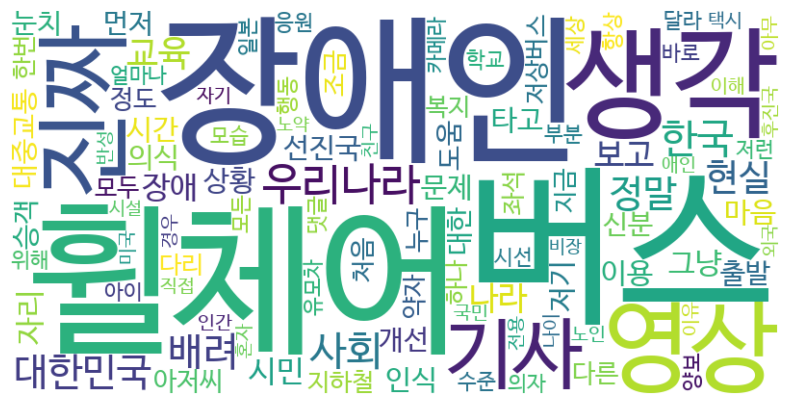

In [62]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create a dictionary of word frequencies
word_freq = dict(zip(keywords_df['단어'], keywords_df['빈도수']))

# Set font path for Korean characters
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # Adjust if necessary

# Create a WordCloud object
wordcloud = WordCloud(
    font_path=font_path,
    width=800,
    height=400,
    background_color='white',
    colormap="viridis"
).generate_from_frequencies(word_freq)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('', fontsize=16)
plt.show()